<a href="https://colab.research.google.com/github/rtmyy/master-is-project/blob/main/train_model_with_mock_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

In [3]:
np.random.seed(42)
n = 300

In [4]:
data = pd.DataFrame({
    "career_growth": np.random.randint(1, 6, n),
    "compensation": np.random.randint(1, 6, n),
    "training": np.random.randint(1, 6, n),
    "management_support": np.random.randint(1, 6, n),
    "skill_match": np.random.randint(1, 6, n),
    "role_clarity": np.random.randint(1, 6, n),
    "major_match": np.random.randint(1, 6, n),
})

In [5]:
# สร้าง psychological mediators แบบมีความสัมพันธ์สมเหตุสมผล
data["job_satisfaction"] = (
    0.3 * data["career_growth"] +
    0.3 * data["management_support"] +
    0.2 * data["skill_match"] +
    np.random.normal(0, 0.5, n)
).round().clip(1,5)

In [6]:
data["organizational_commitment"] = (
    0.3 * data["management_support"] +
    0.3 * data["career_growth"] +
    0.2 * data["major_match"] +
    np.random.normal(0, 0.5, n)
).round().clip(1,5)

In [7]:
# สร้าง Turnover Intention (เชิงลบกับ JS และ OC)
data["turnover_intention_score"] = (
    6 - (
        0.4 * data["job_satisfaction"] +
        0.4 * data["organizational_commitment"]
    ) +
    np.random.normal(0, 0.5, n)
).round().clip(1,5)

In [8]:
# แปลงเป็น classification
data["turnover_risk"] = np.where(data["turnover_intention_score"] >= 4, 1, 0)

In [9]:
print(data.head())

   career_growth  compensation  training  management_support  skill_match  \
0              4             5         3                   3            2   
1              5             5         4                   1            4   
2              3             1         5                   5            3   
3              5             5         4                   4            1   
4              5             3         3                   4            3   

   role_clarity  major_match  job_satisfaction  organizational_commitment  \
0             4            3               2.0                        3.0   
1             2            4               3.0                        2.0   
2             4            2               3.0                        3.0   
3             3            4               3.0                        4.0   
4             1            5               4.0                        3.0   

   turnover_intention_score  turnover_risk  
0                       4.0  

## Preparation data and model

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [11]:
# แยก X และ y
X = data.drop(columns=["turnover_intention_score", "turnover_risk"])
y = data["turnover_risk"]

In [12]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

### Logistic Regression

In [13]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [14]:
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

In [15]:
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1:", f1_score(y_test, y_pred_log))
print("AUC:", roc_auc_score(y_test, y_prob_log))

Logistic Regression
Accuracy: 0.8555555555555555
Recall: 0.9733333333333334
F1: 0.9182389937106918
AUC: 0.8960000000000001


### Random Forest

In [16]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [17]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [18]:
print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))


Random Forest
Accuracy: 0.8444444444444444
Recall: 0.96
F1: 0.9113924050632911
AUC: 0.7777777777777778


### Plot ROC Curve

In [19]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

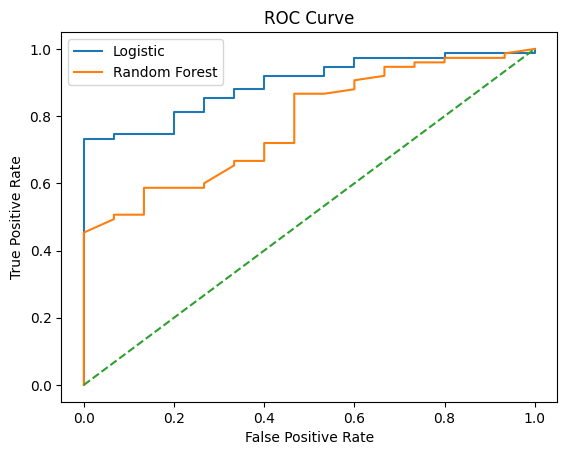

In [20]:
plt.figure()
plt.plot(fpr_log, tpr_log, label="Logistic")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Features importance

In [21]:
importances = rf_model.feature_importances_
features = X.columns

In [22]:
importance_df = (
    pd.DataFrame({"Feature": features, "Importance": importances})
    .sort_values(by="Importance", ascending=False)
)


In [23]:
print(importance_df)

                     Feature  Importance
7           job_satisfaction    0.160104
8  organizational_commitment    0.154508
0              career_growth    0.122599
1               compensation    0.102635
5               role_clarity    0.100375
3         management_support    0.098856
4                skill_match    0.087876
6                major_match    0.087507
2                   training    0.085541


### Logistic Coefficients (ดูทิศทาง + / −)

In [26]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

In [28]:
# ค่า + = เพิ่ม risk
# ค่า − = ลด risk
print(coef_df)

                     Feature  Coefficient
1               compensation     0.112397
6                major_match     0.111696
3         management_support     0.108310
2                   training    -0.011834
5               role_clarity    -0.046031
4                skill_match    -0.072111
0              career_growth    -0.217682
7           job_satisfaction    -1.152235
8  organizational_commitment    -1.247093
